# Model Training & Final Predictions

The final phase of our workflow focuses on building automated preprocessing pipelines and optimizing machine learning algorithms. We handle categorical features using One-Hot Encoding and perform hyperparameter tuning to find the best model configuration. Finally, the top-performing model is deployed onto the unlabeled test dataset to generate our final predictions for submission.

In [8]:
import os
import sys

# Navigate up from 'notebooks' and append the core project directory to the system path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

In [ ]:
# Import all the necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from numpy import random
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils import get_mae, plot_param_vs_mae

In [10]:
# Read the dataset
mortgage_data = pd.read_csv('../data/mortgage_loan_dataset.csv')

# Convert the target variable to an integer to optimize memory and data types
mortgage_data['Max Loan Amount (USD)'] = mortgage_data['Max Loan Amount (USD)'].astype('int64')

# Separate the target variable 'y' for future model training
y = mortgage_data['Max Loan Amount (USD)']
y

0        498842
1        536232
2        518884
3        757940
4        283110
          ...  
49985    995780
49986    659523
49987    354407
49988    713931
49989    688714
Name: Max Loan Amount (USD), Length: 49990, dtype: int64

In [11]:
# Create the feature matrix X by dropping the target column
X = mortgage_data.drop('Max Loan Amount (USD)', axis=1)
# Display the first 5 rows
X.head()

,Gender,Age,Married,Education,Job,Employment Years,Annual Income (USD),Interest Rate,Down Payment (USD),Credit Score,Existing Monthly Debt (USD),Area,Loans Repaid
0,Male,36,Yes,PhD,Software Engineer,13,134183.86,0.08,101706.78,682,2045.80,Urban,3
1,Female,63,No,High School,Freelancer,37,68884.95,0.03,46324.29,823,804.73,Suburban,10
2,Female,33,Yes,PhD,Nurse,11,76396.27,0.03,13045.79,813,1050.54,Urban,0
3,Female,51,Yes,Bachelor's,Business Owner,29,115968.80,0.05,60388.40,752,904.08,Rural,2
4,Male,53,Yes,Bachelor's,Nurse,27,99977.38,0.06,54838.14,728,2285.76,Rural,1


In [12]:
# Perform a two-stage split to create training (60%), validation (20%), and testing (20%) datasets
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=1)

In [13]:
# Identify string columns and separate them by cardinality to manage high-dimensional categorical features
object_cols = [col for col in X_train.columns if X_train[col].dtype == 'str']
low_cardinality_cols = [col for col in object_cols if X_train[col].nunique() <= 15]
high_cardinality_cols = list(set(object_cols) - set(low_cardinality_cols))

# Drop high-cardinality features across all splits to prevent overfitting and excessive feature expansion
X_train.drop(high_cardinality_cols, axis=1, inplace=True)
X_val.drop(high_cardinality_cols, axis=1, inplace=True)
X_test.drop(high_cardinality_cols, axis=1, inplace=True)

In [14]:
# Define active features and configure a robust ColumnTransformer for numeric and categorical types
categorical_cols = low_cardinality_cols
numeric_cols = [cname for cname in X_train.columns if X_train[cname].dtype in ['int64', 'float64']]

# Set up a baseline imputer to fill missing numeric data with a constant placeholder value
numerical_transformer = SimpleImputer(strategy='constant')

# Set up a preprocessing pipeline to apply One-Hot Encoding to valid categorical features
categorical_transformer = Pipeline(
    steps = [('onehot', OneHotEncoder(handle_unknown='ignore'))]
)

# Bundle both column transformations into a single, structured preprocessor object
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])


In [15]:
# Generate a reproducible random list of max_leaf_nodes to hyperparameter tune the model
random.seed(42)

leaf_size = random.randint(1, 500, 10).tolist()
leaf_size

[103, 436, 349, 271, 107, 72, 189, 21, 103, 122]

Parameter max_leaf_nodes = 21   | MAE: 94783.1205
Parameter max_leaf_nodes = 72   | MAE: 66309.2918
Parameter max_leaf_nodes = 103  | MAE: 59901.8314
Parameter max_leaf_nodes = 107  | MAE: 59627.8051
Parameter max_leaf_nodes = 122  | MAE: 57701.4046
Parameter max_leaf_nodes = 189  | MAE: 52766.2860
Parameter max_leaf_nodes = 271  | MAE: 48740.8084
Parameter max_leaf_nodes = 349  | MAE: 46272.5419
Parameter max_leaf_nodes = 436  | MAE: 44234.9388


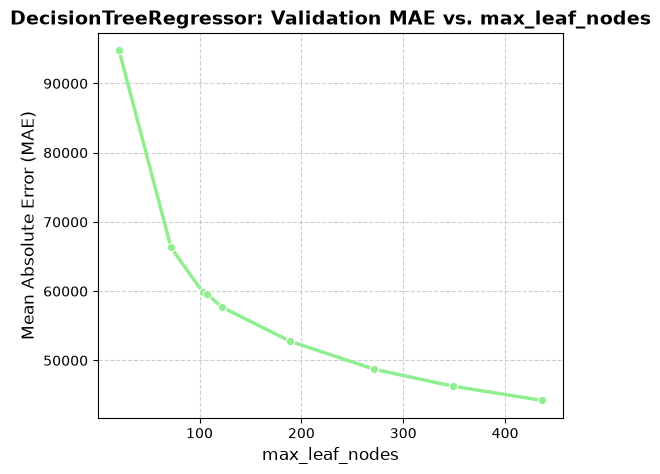

436

In [16]:
# Tune and plot the MAE curve for DecisionTreeRegressor to find the optimal max_leaf_nodes
plot_param_vs_mae(DecisionTreeRegressor, 'max_leaf_nodes', leaf_size, X_train, y_train, X_val, y_val, preprocessor)

By letting the model grow larger, the Mean Absolute Error (MAE) dropped significantly from around $234,000 down to $44,234. Setting max_leaf_nodes to 436 gave the Decision Tree enough freedom to capture the complex lending rules in the data instead of forcing applicants into a few generic average buckets.

In [17]:
# Generate a reproducible random list of n_estimators (tree counts) to tune Random Forest model
random.seed(42)

trees_number = random.randint(15, 400, 10).tolist()
trees_number

[117, 363, 285, 121, 86, 203, 35, 117, 136, 229]

Parameter n_estimators = 35   | MAE: 19830.7023
Parameter n_estimators = 86   | MAE: 19373.9113
Parameter n_estimators = 117  | MAE: 19331.9954
Parameter n_estimators = 121  | MAE: 19328.2236
Parameter n_estimators = 136  | MAE: 19275.0198
Parameter n_estimators = 203  | MAE: 19218.1864
Parameter n_estimators = 229  | MAE: 19208.4466
Parameter n_estimators = 285  | MAE: 19205.0221
Parameter n_estimators = 363  | MAE: 19202.4064


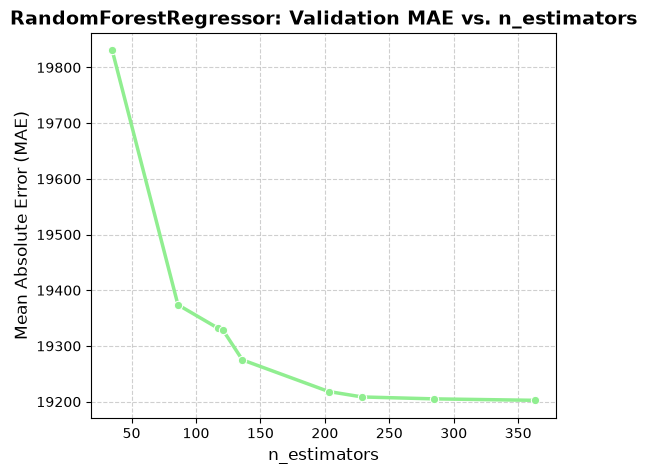

363

In [18]:
# Execute the hyperparameter tuning function to find the optimal number of trees for a Random Forest
plot_param_vs_mae(RandomForestRegressor, 'n_estimators', trees_number, X_train, y_train, X_val, y_val, preprocessor)

Switching to a Random Forest dropped the error even lower, bringing the Mean Absolute Error (MAE) down to just $19,202.41 with 363 trees. Because a Random Forest combines the guesses of hundreds of different trees instead of relying on just one, it drastically reduced the mistakes and successfully captured the fine details in the dataset.

In [19]:
# Generate a reproducible random list of estimator counts to hyperparameter tune an ensemble model
random.seed(42)

estimators_list = random.randint(100, 1000, 10).tolist()
estimators_list

[202, 535, 960, 370, 206, 171, 800, 120, 714, 221]

Parameter n_estimators = 120  | MAE: 16842.5117
Parameter n_estimators = 171  | MAE: 15666.9414
Parameter n_estimators = 202  | MAE: 15379.8057
Parameter n_estimators = 206  | MAE: 15361.8740
Parameter n_estimators = 221  | MAE: 15285.8750
Parameter n_estimators = 370  | MAE: 14844.8252
Parameter n_estimators = 535  | MAE: 14652.0820
Parameter n_estimators = 714  | MAE: 14549.2461
Parameter n_estimators = 800  | MAE: 14511.2158
Parameter n_estimators = 960  | MAE: 14467.1445


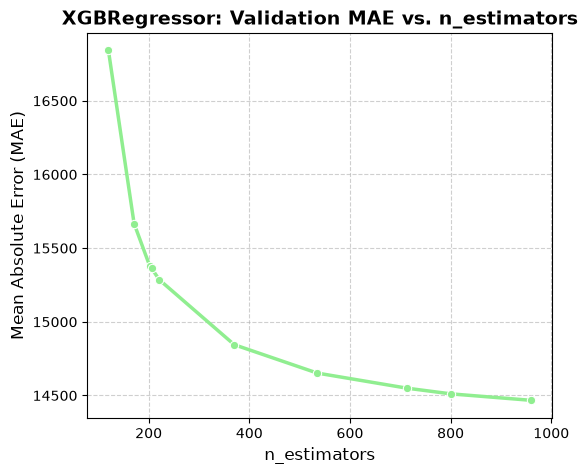

960

In [20]:
# Execute the hyperparameter tuning function to find the optimal n_estimators for an XGBoost Regressor
plot_param_vs_mae(XGBRegressor, 'n_estimators', estimators_list, X_train, y_train, X_val, y_val, preprocessor, learning_rate=0.05, n_jobs=4)

The XGBoost model achieved the absolute best performance, driving the Mean Absolute Error (MAE) down to just $14,467.14 using 960 trees. By focusing on fixing the mistakes of previous trees step-by-step (boosting), XGBoost successfully squeezed out the remaining errors and proved to be the most accurate algorithm for predicting the loan amounts.

In [21]:
# Collect validation MAE scores for all optimized models and identify the best-performing algorithm
model_result = {}
model_result['Decision Tree'] = get_mae(DecisionTreeRegressor(max_leaf_nodes=436, random_state=0), X_train, y_train, X_val, y_val, preprocessor)
model_result['Random Forest'] = get_mae(RandomForestRegressor(n_estimators=363, random_state=0), X_train, y_train, X_val, y_val, preprocessor)
model_result['XGBRegressor'] = get_mae(XGBRegressor(n_estimators=960, learning_rate=0.05, n_jobs=4, random_state=0), X_train, y_train, X_val, y_val, preprocessor)

# Determine the model with the minimum Mean Absolute Error
best_model = min(model_result, key=model_result.get)
best_model


'XGBRegressor'

The overall model comparison confirms XGBoost (XGBRegressor) as the winning algorithm for this dataset. By un-capping the parameters and letting the models grow, XGBoost successfully minimized the validation error down to its lowest point, drastically outperforming the simple Decision Tree. This proves that an ensemble boosting method is highly effective at learning the intricate, non-linear financial patterns and strict banking rules hidden within your data.

In [22]:
# Construct the final pipeline with the chosen model and evaluate it on the held-out test data
new_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', XGBRegressor(n_estimators=960, learning_rate=0.05, n_jobs=4, random_state=0))
    ])

# Fit the model on the full training partition and generate test predictions
new_pipeline.fit(X_temp, y_temp)
predictions = new_pipeline.predict(X_test)
mean_absolute_error(y_test, predictions)

14489.3583984375

The final evaluation on the held-out test data yields a Mean Absolute Error (MAE) of $14,489.36, proving that the optimized XGBoost pipeline generalizes exceptionally well to completely unseen data. This stable result closely mirrors the validation error (~$14,467), mathematically confirming that the model is not overfitting. For a target variable that spans up to $2.2 million, an average error of just under $14.5k indicates high predictive precision across the entire applicant pool.

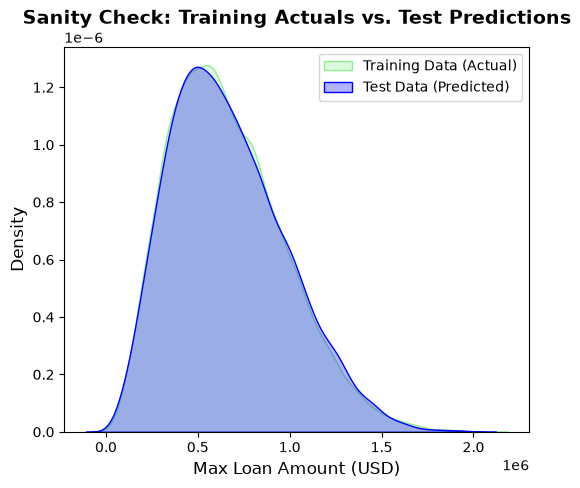

In [23]:
plt.figure(figsize=(6, 5))

# Plot training labels distribution vs the test predictions distribution
sns.kdeplot(y_train, label='Training Data (Actual)', color='lightgreen', fill=True, alpha=0.3)
sns.kdeplot(predictions, label='Test Data (Predicted)', color='blue', fill=True, alpha=0.3)

plt.title('Sanity Check: Training Actuals vs. Test Predictions', fontsize=14, fontweight='bold')
plt.xlabel('Max Loan Amount (USD)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.show()

The density plot evaluates the baseline model's performance by comparing the actual training data distribution against the test predictions. The model's prediction curve (blue) remarkably tracks the overall shape, spread, and right-skew of the actual loan amount distribution (green). It successfully captures both the peak density around $500,000 and the long right tail extending past $1.5 million.The minor jagged ripples on the blue prediction curve suggest that the model is already isolating specific, sharp decision boundaries within the features rather than over-smoothing the outputs. Overall, this alignment indicates that the initial model setup effectively avoids severe underfitting and has successfully learned the core patterns governing the target variable right from the start.

Limitations of the Study
- Unaddressed Right-Skewness: The model closely follows the long right tail of Max Loan Amount (USD) without target transformation, meaning extreme upper-bound outliers could still disproportionately influence and bias model errors.
- Artificial Boundary Spikes: The jagged ripples in the blue prediction curve suggest the model is locking onto the strict data caps present in features like Credit Score (850) and Employment Years (50), potentially masking true applicant variance.
- Synthetic Pattern Dependency: The model relies on a highly curated dataset with perfectly uniform age brackets and identical job group frequencies, which does not represent the unstratified, messy distributions of real-world banking applicants.
- Rigid Institutional Rules: Because features like Interest Rate contain fixed corporate pricing tiers, the model's learned logic is limited to this specific organization's policies and cannot easily generalize to a fluid market.